/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (0,1,3,4,5,6) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


Original 'citation00_10.csv' CSV Data: 

            Patent    Cit_Date            Cit_Name Cit_Kind Cit_Country  \
0          6009555  1980-03-01                 FAY      NaN         NaN   
1          6009555  1985-10-01        BROWN ET AL.      NaN         NaN   
2          6009555  1988-09-01             SCHRACK      NaN         NaN   
3          6009555  1990-08-01               MOODY      NaN         NaN   
4          6009555  1992-04-01         LYND ET AL.      NaN         NaN   
...            ...         ...                 ...      ...         ...   
37225308  RE370053  1993-11-01    SUTTERLIN ET AL.      NaN         NaN   
37225309  RE370053  1995-03-01        KOZAK ET AL.      NaN         NaN   
37225310  RE370053  1995-06-01          SCHMEIDING      NaN         NaN   
37225311  RE370053  1996-01-01           MICHELSON      NaN         NaN   
37225312  RE370053  1997-05-01  SCARBOROUGH ET AL.      NaN         NaN   

          Citation Category  CitSeq  
0         04192017  

In [1]:
import pandas as pd

# Load the dataset (replace 'your_dataset.csv' with the actual file path)
df = pd.read_csv('subset_dataset.csv', usecols=['Patent', 'Cit_Date', 'Citation'])

# Select the first 10,000,000 rows
df_subset = df.head(10000)

# Save the selected rows to a new CSV file
df_subset.to_csv('subset_dataset4.csv', index=False)


Number of nodes: 10727
Number of edges: 10000
Number of nodes after densification: 10827
Number of edges after densification: 10226


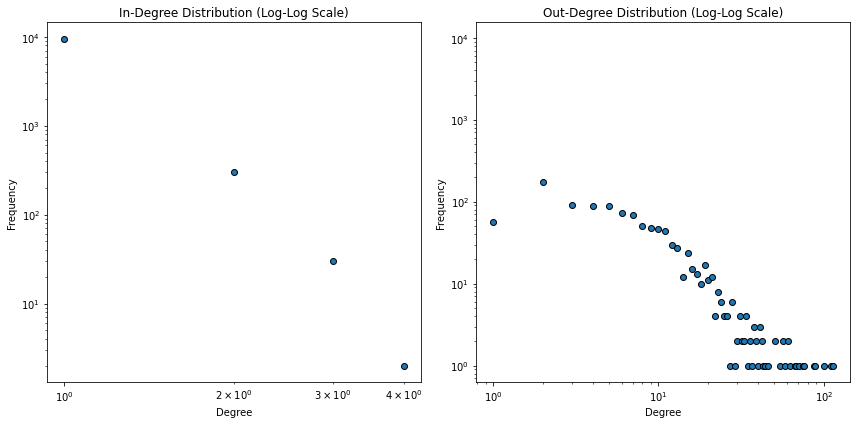

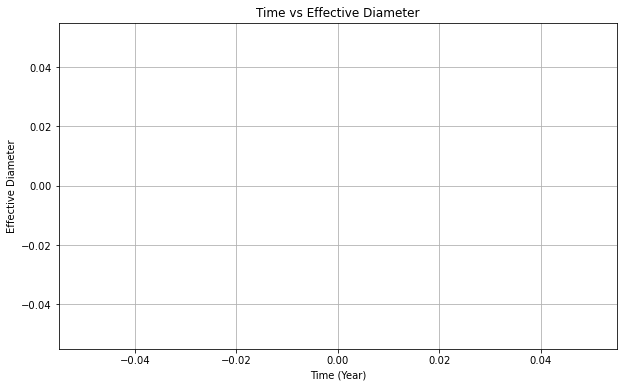

In [4]:
import pandas as pd

# Read the CSV file
file_path = 'subset_dataset4.csv'  # Replace with your actual file path
df = pd.read_csv(file_path)

# Extract the year from the second column
df.iloc[:, 1] = df.iloc[:, 1].apply(lambda x: x.split('-')[0])

# Save the modified data to a new CSV file
output_file_path = 'subset_dataset4a.csv'  # Replace with your desired output file path
df.to_csv(output_file_path, index=False)

print(f"Modified file saved to {output_file_path}")


Modified file saved to subset_dataset4a.csv


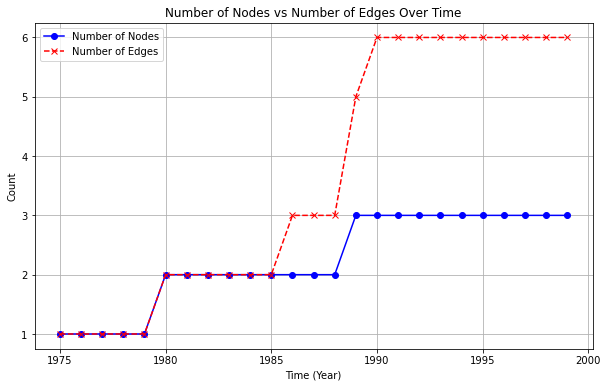

In [8]:
import pandas as pd
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'subset_dataset3a.csv'  # Update with your actual file path
df = pd.read_csv(file_path)

# Ensure the CSV has the necessary columns
required_columns = ['Patent', 'Cit_Date', 'Citation']
assert all(col in df.columns for col in required_columns), f"CSV must contain columns: {required_columns}"

# Convert Cit_Date to integer
df['Cit_Date'] = df['Cit_Date'].astype(int)

# Create a directed graph
G = nx.DiGraph()

# Parameters for the Forest Fire model
p = 0.35  # Forward burning probability
r = 0.32  # Backward burning ratio

# Function to generate geometrically distributed random numbers
def geometric_random(mean):
    return np.random.geometric(1 / mean)

# Lists to store number of nodes and edges over time
years = sorted(df['Cit_Date'].unique())
num_nodes_over_time = []
num_edges_over_time = []

# Apply the Forest Fire model to the graph
for index, row in df.iterrows():
    new_node = str(row['Patent'])
    G.add_node(new_node)
    
    # Step (i): Select an ambassador node uniformly at random
    if len(G) > 0:
        ambassador_node = random.choice(list(G.nodes))
    else:
        ambassador_node = None
    
    if ambassador_node:
        G.add_edge(new_node, ambassador_node)
        
        # Step (ii) and (iii): Generate x and y, select out-links and in-links
        x = geometric_random((1 - p) ** -1)
        y = geometric_random((1 - r * p) ** -1)
        
        # Select out-links and in-links to burn
        out_links = random.sample(list(G.out_edges(ambassador_node)), min(x, G.out_degree(ambassador_node)))
        in_links = random.sample(list(G.in_edges(ambassador_node)), min(y, G.in_degree(ambassador_node)))
        
        selected_links = out_links + in_links
        
        for edge in selected_links:
            target_node = edge[1] if edge in out_links else edge[0]
            if not G.has_edge(new_node, target_node):
                G.add_edge(new_node, target_node)
            
            # Recursive step
            forest_fire_recursive(G, new_node, target_node, p, r)
    
    # Track number of nodes and edges at each time step
    num_nodes_over_time.append(len(G))
    num_edges_over_time.append(G.number_of_edges())

def forest_fire_recursive(G, current_node, target_node, p, r):
    if G.has_edge(current_node, target_node):
        return
    
    G.add_edge(current_node, target_node)
    
    # Generate geometric random numbers
    x = geometric_random((1 - p) ** -1)
    y = geometric_random((1 - r * p) ** -1)
    
    # Select out-links and in-links to burn
    out_links = random.sample(list(G.out_edges(target_node)), min(x, G.out_degree(target_node)))
    in_links = random.sample(list(G.in_edges(target_node)), min(y, G.in_degree(target_node)))
    
    selected_links = out_links + in_links
    
    for edge in selected_links:
        next_target_node = edge[1] if edge in out_links else edge[0]
        if not G.has_edge(current_node, next_target_node):
            G.add_edge(current_node, next_target_node)
        forest_fire_recursive(G, current_node, next_target_node, p, r)

# Plotting number of nodes vs number of edges over time
plt.figure(figsize=(10, 6))
plt.plot(years, num_nodes_over_time[:len(years)], marker='o', linestyle='-', color='b', label='Number of Nodes')
plt.plot(years, num_edges_over_time[:len(years)], marker='x', linestyle='--', color='r', label='Number of Edges')
plt.title('Number of Nodes vs Number of Edges Over Time')
plt.xlabel('Time (Year)')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()


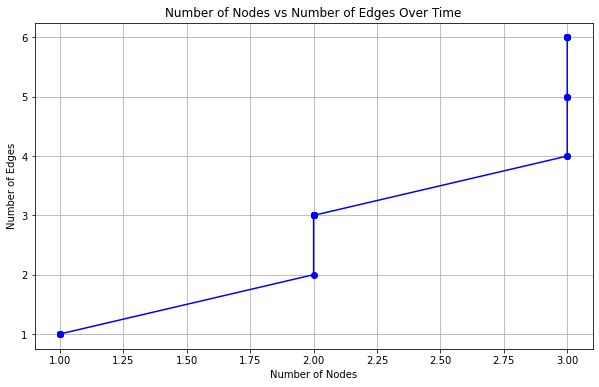

In [9]:
import pandas as pd
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'subset_dataset3a.csv'  # Update with your actual file path
df = pd.read_csv(file_path)

# Ensure the CSV has the necessary columns
required_columns = ['Patent', 'Cit_Date', 'Citation']
assert all(col in df.columns for col in required_columns), f"CSV must contain columns: {required_columns}"

# Convert Cit_Date to integer
df['Cit_Date'] = df['Cit_Date'].astype(int)

# Create a directed graph
G = nx.DiGraph()

# Parameters for the Forest Fire model
p = 0.35  # Forward burning probability
r = 0.32  # Backward burning ratio

# Function to generate geometrically distributed random numbers
def geometric_random(mean):
    return np.random.geometric(1 / mean)

# Lists to store number of nodes and edges over time
years = sorted(df['Cit_Date'].unique())
num_nodes_over_time = []
num_edges_over_time = []

# Apply the Forest Fire model to the graph
for index, row in df.iterrows():
    new_node = str(row['Patent'])
    G.add_node(new_node)
    
    # Step (i): Select an ambassador node uniformly at random
    if len(G) > 0:
        ambassador_node = random.choice(list(G.nodes))
    else:
        ambassador_node = None
    
    if ambassador_node:
        G.add_edge(new_node, ambassador_node)
        
        # Step (ii) and (iii): Generate x and y, select out-links and in-links
        x = geometric_random((1 - p) ** -1)
        y = geometric_random((1 - r * p) ** -1)
        
        # Select out-links and in-links to burn
        out_links = random.sample(list(G.out_edges(ambassador_node)), min(x, G.out_degree(ambassador_node)))
        in_links = random.sample(list(G.in_edges(ambassador_node)), min(y, G.in_degree(ambassador_node)))
        
        selected_links = out_links + in_links
        
        for edge in selected_links:
            target_node = edge[1] if edge in out_links else edge[0]
            if not G.has_edge(new_node, target_node):
                G.add_edge(new_node, target_node)
            
            # Recursive step
            forest_fire_recursive(G, new_node, target_node, p, r)
    
    # Track number of nodes and edges at each time step
    num_nodes_over_time.append(len(G))
    num_edges_over_time.append(G.number_of_edges())

def forest_fire_recursive(G, current_node, target_node, p, r):
    if G.has_edge(current_node, target_node):
        return
    
    G.add_edge(current_node, target_node)
    
    # Generate geometric random numbers
    x = geometric_random((1 - p) ** -1)
    y = geometric_random((1 - r * p) ** -1)
    
    # Select out-links and in-links to burn
    out_links = random.sample(list(G.out_edges(target_node)), min(x, G.out_degree(target_node)))
    in_links = random.sample(list(G.in_edges(target_node)), min(y, G.in_degree(target_node)))
    
    selected_links = out_links + in_links
    
    for edge in selected_links:
        next_target_node = edge[1] if edge in out_links else edge[0]
        if not G.has_edge(current_node, next_target_node):
            G.add_edge(current_node, next_target_node)
        forest_fire_recursive(G, current_node, next_target_node, p, r)

# Plotting number of nodes vs number of edges over time
plt.figure(figsize=(10, 6))
plt.plot(num_nodes_over_time[:len(years)], num_edges_over_time[:len(years)], marker='o', linestyle='-', color='b')
plt.title('Number of Nodes vs Number of Edges Over Time')
plt.xlabel('Number of Nodes')
plt.ylabel('Number of Edges')
plt.grid(True)
plt.show()


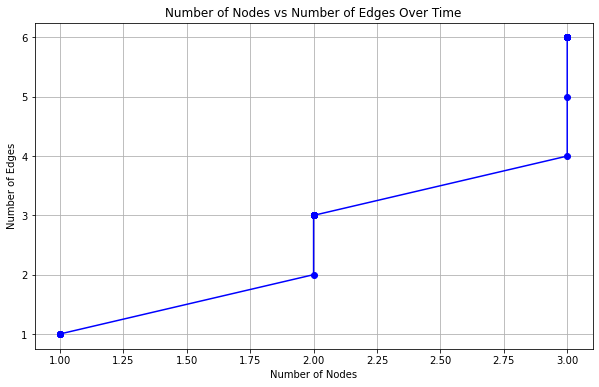

In [11]:
import pandas as pd
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'subset_dataset4a.csv'  # Update with your actual file path
df = pd.read_csv(file_path)

# Ensure the CSV has the necessary columns
required_columns = ['Patent', 'Cit_Year', 'Citation']
assert all(col in df.columns for col in required_columns), f"CSV must contain columns: {required_columns}"

# Convert Cit_Date to integer
df['Cit_Year'] = df['Cit_Year'].astype(int)

# Create a directed graph
G = nx.DiGraph()

# Parameters for the Forest Fire model
p = 0.35  # Forward burning probability
r = 0.32  # Backward burning ratio

# Function to generate geometrically distributed random numbers
def geometric_random(mean):
    return np.random.geometric(1 / mean)

# Lists to store number of nodes and edges over time
years = sorted(df['Cit_Year'].unique())
num_nodes_over_time = []
num_edges_over_time = []

# Apply the Forest Fire model to the graph
for index, row in df.iterrows():
    new_node = str(row['Patent'])
    G.add_node(new_node)
    
    # Step (i): Select an ambassador node uniformly at random
    if len(G) > 0:
        ambassador_node = random.choice(list(G.nodes))
    else:
        ambassador_node = None
    
    if ambassador_node:
        G.add_edge(new_node, ambassador_node)
        
        # Step (ii) and (iii): Generate x and y, select out-links and in-links
        x = geometric_random((1 - p) ** -1)
        y = geometric_random((1 - r * p) ** -1)
        
        # Select out-links and in-links to burn
        out_links = random.sample(list(G.out_edges(ambassador_node)), min(x, G.out_degree(ambassador_node)))
        in_links = random.sample(list(G.in_edges(ambassador_node)), min(y, G.in_degree(ambassador_node)))
        
        selected_links = out_links + in_links
        
        for edge in selected_links:
            target_node = edge[1] if edge in out_links else edge[0]
            if not G.has_edge(new_node, target_node):
                G.add_edge(new_node, target_node)
            
            # Recursive step
            forest_fire_recursive(G, new_node, target_node, p, r)
    
    # Track number of nodes and edges at each time step
    num_nodes_over_time.append(len(G))
    num_edges_over_time.append(G.number_of_edges())

def forest_fire_recursive(G, current_node, target_node, p, r):
    if G.has_edge(current_node, target_node):
        return
    
    G.add_edge(current_node, target_node)
    
    # Generate geometric random numbers
    x = geometric_random((1 - p) ** -1)
    y = geometric_random((1 - r * p) ** -1)
    
    # Select out-links and in-links to burn
    out_links = random.sample(list(G.out_edges(target_node)), min(x, G.out_degree(target_node)))
    in_links = random.sample(list(G.in_edges(target_node)), min(y, G.in_degree(target_node)))
    
    selected_links = out_links + in_links
    
    for edge in selected_links:
        next_target_node = edge[1] if edge in out_links else edge[0]
        if not G.has_edge(current_node, next_target_node):
            G.add_edge(current_node, next_target_node)
        forest_fire_recursive(G, current_node, next_target_node, p, r)

# Plotting number of nodes vs number of edges over time
plt.figure(figsize=(10, 6))
plt.plot(num_nodes_over_time[:len(years)], num_edges_over_time[:len(years)], marker='o', linestyle='-', color='b')
plt.title('Number of Nodes vs Number of Edges Over Time')
plt.xlabel('Number of Nodes')
plt.ylabel('Number of Edges')
plt.grid(True)
plt.show()
